# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** Genta Hayindra Irawan
- **Email:** genta.h.irawan@gmail.com
- **ID Dicoding:** GenSky

## Menentukan Pertanyaan Bisnis

- Bagaimana tingkat peminjaman sepeda setiap bulan selama dua tahun ini (2011-2012)?
- Bagaimana tingkat frekuensi pengguna kasual atau teregistrasi dalam peminjaman sepeda setiap jam nya?
- Bagaimana perbandingan peminjaman pengguna kasual dan teregistrasi ketika waktu kerja atau libur?
- Bagaimana tingkat peminjaman sepeda setiap musimnya selama dua tahun ini?


## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Data Wrangling

### Gathering Data

In [2]:
#registrasi path drive ke notebook colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
os.chdir('/content/drive/My Drive/Colab Notebooks/TA data analisis')

In [4]:
hour_df = pd.read_csv('hour.csv')

In [5]:
day_df = pd.read_csv('day.csv')

In [6]:
hour_df.head().tail()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [7]:
day_df.head().tail()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [8]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [9]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB



Tidak ada colom yang kosong pada kedua dataset



**Insight:**
- Nilai pada suhu perlu dikembalikan sebelum dalam bentuk normalisasinya
- Tipe data tanggal perlu diganti menjadi datetime
- Nama tabel perlu diganti agar lebih jelas
- Isi kategori pada season dan weathersit akan diperjelas

### Assessing Data

In [10]:
hour_df.groupby('yr').agg({
    'casual': 'sum',
    'registered': 'sum'
})

,casual,registered
yr,,
0,247252,995851
1,372765,1676811


In [11]:
day_df.groupby('yr').agg({
    'casual': 'sum',
    'registered': 'sum'
})

,casual,registered
yr,,
0,247252,995851
1,372765,1676811


Kedua data memiliki jumlah yang sama

In [12]:
hour_df.rename(columns={
    'instant': 'borrow_id',
    'dteday': 'date',
    'mnth': 'month',
    'hr': 'hour',
    'yr' : 'year',
    'holiday': 'is_holiday',
    'workingday': 'is_workingday',
    'cnt' : 'total_users'
}, inplace=True)

In [13]:
hour_df.describe()

,borrow_id,season,year,month,hour,is_holiday,weekday,is_workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,total_users
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [14]:
hour_df.nunique()

,0
borrow_id,17379
date,731
season,4
year,2
month,12
hour,24
is_holiday,2
weekday,7
is_workingday,2
weathersit,4


**Insight:**
- Borrow_id tidak ada duplikat, untuk date atau tanggal benar berjumlah 731 karena 2012 adalah tahun kabisat
- Data pada hour.csv akan digunakan karena lebih mendetail hingga ke jam peminjaman sepeda
- Semua kategori yang lain berjumlah sebagaimana seharusnya

### Cleaning Data

In [15]:
#kesalahan tipe data pada kolom date, diubah dari object menjadi date
hour_df['date'] = pd.to_datetime(hour_df['date'])

In [16]:
#mengganti tipe data pada musim, tahun, bulan, jam, is_holiday, weekday, is_workingday, dan weathersit menjadi kategori
kolom = ['season', 'year', 'month', 'hour', 'is_holiday', 'weekday', 'is_workingday', 'weathersit']
for col in kolom:
  hour_df[col] = hour_df[col].astype('category')

In [17]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   borrow_id      17379 non-null  int64         
 1   date           17379 non-null  datetime64[ns]
 2   season         17379 non-null  category      
 3   year           17379 non-null  category      
 4   month          17379 non-null  category      
 5   hour           17379 non-null  category      
 6   is_holiday     17379 non-null  category      
 7   weekday        17379 non-null  category      
 8   is_workingday  17379 non-null  category      
 9   weathersit     17379 non-null  category      
 10  temp           17379 non-null  float64       
 11  atemp          17379 non-null  float64       
 12  hum            17379 non-null  float64       
 13  windspeed      17379 non-null  float64       
 14  casual         17379 non-null  int64         
 15  registered     1737

In [18]:
#Mengganti nilai pada Kolom season menjadi lebih deskriptif
hour_df['season'] = hour_df['season'].map({
    1: 'spring',
    2: 'summer',
    3: 'fall',
    4: 'winter'
})

In [19]:
#Mengganti nilai pada kolom weathersit menjadi lebih deskriptif
hour_df['weathersit'] = hour_df['weathersit'].map({
    1: 'Clear/Few clouds',
    2: 'Mist + Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Snow/Rain'
})

In [20]:
#mengganti nilai pada kolom weekday menjadi lebih deskriptif
hour_df['weekday'] = hour_df['weekday'].map({
    0: 'Minggu',
    1: 'Senin',
    2: 'Selasa',
    3: 'Rabu',
    4: 'Kamis',
    5: "Jum'at",
    6: 'Sabtu'
})

In [21]:
#mengganti nilai pada is_holiday weekday menjadi lebih deskriptif
hour_df['is_holiday'] = hour_df['is_holiday'].map({
    0: 'Tidak',
    1: 'Ya'
})

In [22]:
#mengganti nilai pada is_workingday weekday menjadi lebih deskriptif
hour_df['is_workingday'] = hour_df['is_workingday'].map({
    0: 'Bukan',
    1: 'Ya'
})

**Insight:**
- Dengan mengganti kategori pada musim dan cuaca akan lebih mudah ketika mengeksplor data

## Exploratory Data Analysis (EDA)

### Explore ...

Dari dokumentasi dataset, disebutkan bahwa temperatur sudah dinormalisasikan dengan persamaan:<br> $y=\frac{t-t_{min}}{t_{max}-t_{min}}$ <br><br>
Sehingga untuk mendapatkan suhu yang sebenarnya dapat dicari dengan :<br> $t=y\left( t_{max}-t_{min} \right)+t_{min}$ atau menjadi $t=y\left( 47 \right)-8$ <br> Dimana $y$ merupakan nilai normalisasi dari suhu

In [23]:
#Menggunakan round untuk membatasi bilangan bulat
hour_df['temp'] = round((hour_df['temp']*47)-8, 2)

In [24]:
hour_df['temp'].describe()

,temp
count,17379.000000
mean,15.358397
std,9.050138
min,-7.060000
25%,7.980000
50%,15.500000
75%,23.020000
max,39.000000


In [25]:
#cek suhu berdasarkan musim dan kondisi cuaca
def q1(x):
  return x.quantile(0.25)
def q3(x):
  return x.quantile(0.75)

hour_df.groupby(['season', 'weathersit']).agg({
    'temp' : ['min', q1 , 'mean', q3, 'max']
})

<ipython-input-25-875f9ad81e64>:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hour_df.groupby(['season', 'weathersit']).agg({


temp                                
                           min     q1       mean     q3    max
season weathersit                                             
spring Clear/Few clouds  -7.06   2.34   6.070724   9.86  25.84
       Mist + Cloudy     -7.06   2.34   6.068017   8.92  25.84
       Light Snow/Rain   -4.24   2.34   5.998103   9.86  18.32
       Heavy Snow/Rain   -1.42  -0.01   0.773333   1.87   2.34
summer Clear/Few clouds   0.46  13.62  18.404498  23.02  36.18
       Mist + Cloudy      2.34  11.74  16.716906  21.14  31.48
       Light Snow/Rain   -0.48   8.92  14.414138  19.26  30.54
       Heavy Snow/Rain     NaN    NaN        NaN    NaN    NaN
fall   Clear/Few clouds   9.86  23.02  25.708457  28.66  39.00
       Mist + Cloudy     13.62  22.08  24.140655  26.78  37.12
       Light Snow/Rain   14.56  21.14  22.750929  24.90  35.24
       Heavy Snow/Rain     NaN    NaN        NaN    NaN    NaN
winter Clear/Few clouds  -1.42   7.04  11.387635  15.50  26.78
       Mist + Cloudy     -0.48   7.98  12.561747  16.44  27.72
       Light Snow/Rain    2.34   8.92  13.121173  17.38  23.02
       Heavy Snow/Rain     NaN    NaN        NaN    NaN    NaN

In [26]:
#dicek apakah cuaca hujan/salju berat memang hanya ada pada musim semi
hour_df.loc[hour_df['weathersit'].isin([4])]

,borrow_id,date,season,year,month,hour,is_holiday,weekday,is_workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,total_users


Membuat kategori suhu berdasarkan __[Klasifikasi iklim Köppen](https://upload.wikimedia.org/wikipedia/commons/c/cb/World_K%C3%B6ppen_Map.png)__, lokasi populasi data berasal dari __[Downtown DC](https://storymaps.arcgis.com/stories/b806ee03478e4fac8fe94c0e97c203e2?form=MG0AV3)__. Sehinga patokan kategori akan diambil dari suhu rata-rata iklim subtropis basah __[(Cfa / Cwa)](https://id.wikipedia.org/wiki/Iklim_subtropis_basah)__

In [27]:
#Membuat definisi gerbang logika kategori suhu
def suhu(x):
  if x <= 16.00:
    return 'dingin'
  elif x >= 22.00:
    return 'hangat'
  else:
    return 'sedang'

hour_df['suhu'] = hour_df['temp'].apply(suhu)


In [28]:
hour_df.groupby(by=['season','suhu']).agg({
    'casual': 'sum',
    'registered': 'sum',
    'total_users': 'sum'
})

<ipython-input-28-6517c6158d7c>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hour_df.groupby(by=['season','suhu']).agg({


casual  registered  total_users
season suhu                                   
spring dingin   47491      358273       405764
       hangat    3875       12745        16620
       sedang    9256       39708        48964
summer dingin   39557      179182       218739
       hangat  100103      289337       389440
       sedang   63862      246548       310410
fall   dingin    1405        9594        10999
       hangat  208543      726976       935519
       sedang   16143       98468       114611
winter dingin   64704      456616       521320
       hangat   16392       61498        77890
       sedang   48686      193717       242403

In [29]:
hour_df.groupby(by=['hour','weekday']).agg({
    'casual': 'sum',
    'registered': 'sum',
    'total_users': 'sum'
})

<ipython-input-29-af142cedcfea>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hour_df.groupby(by=['hour','weekday']).agg({


casual  registered  total_users
hour weekday                                 
0    Minggu     1896        7879         9775
     Senin       989        2582         3571
     Selasa      583        2207         2790
     Rabu        611        2983         3594
     Kamis       705        3340         4045
...              ...         ...          ...
23   Selasa     1122        6800         7922
     Rabu       1255        7370         8625
     Kamis      1386        8676        10062
     Jum'at     2027        9955        11982
     Sabtu      2681        9368        12049

[168 rows x 3 columns]

**Insight:**
- Suhu rata rata di sini lebih dingin jika dibanding dengan suhu di indonesia
- Pengguna relatif lebih sering meminjam sepeda ketika musim panas dan gurun
- Pengguna relatif frekuentif ketika sudah memasuki waktu siang

## Visualization & Explanatory Analysis

### Bagaimana tingkat peminjaman sepeda setiap bulan selama dua tahun ini (2011-2012)?

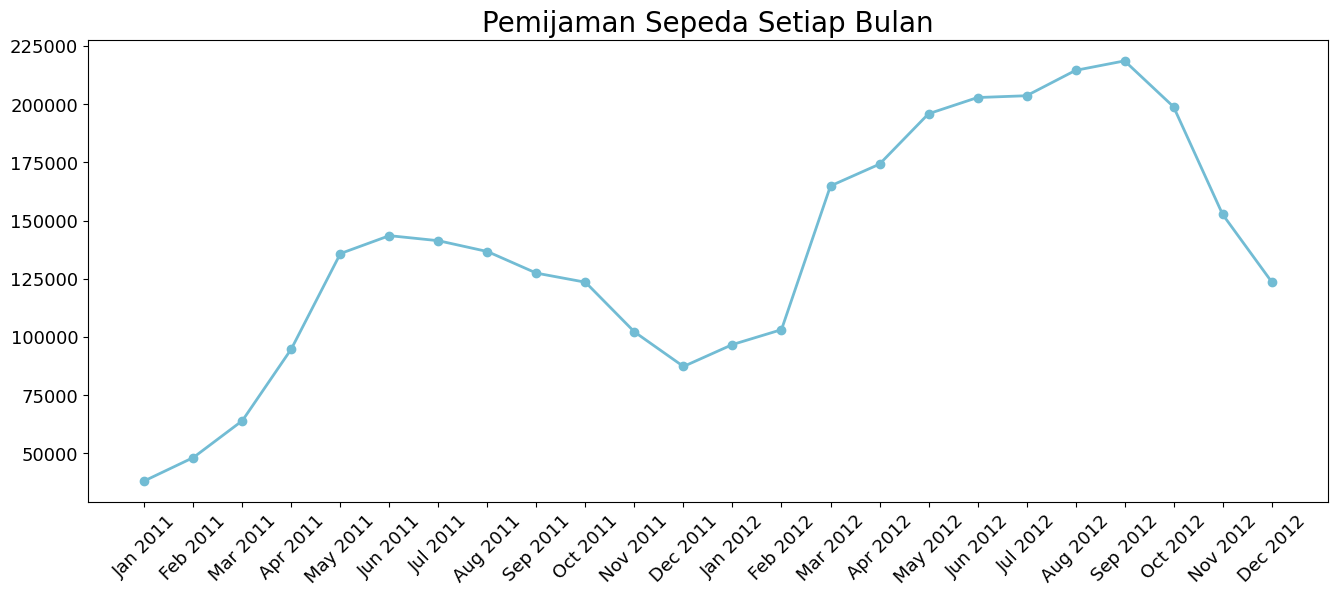

In [45]:
#total peminjaman
monthly_bike_dl = hour_df.resample(rule='ME', on='date').agg({
    'casual': 'sum',
    'registered': 'sum',
    'total_users': 'sum'
})


monthly_bike_dl.index = monthly_bike_dl.index.strftime('%b %Y')
monthly_bike_dl = monthly_bike_dl.reset_index()

plt.figure(figsize=(16, 6))
plt.plot(monthly_bike_dl["date"], monthly_bike_dl["total_users"], marker='o', linewidth=2, color="#72BCD4")
plt.title("Pemijaman Sepeda Setiap Bulan", loc="center", fontsize=20)
plt.xticks(fontsize=13)
plt.xticks(rotation=45)
plt.yticks(fontsize=13)
plt.show()

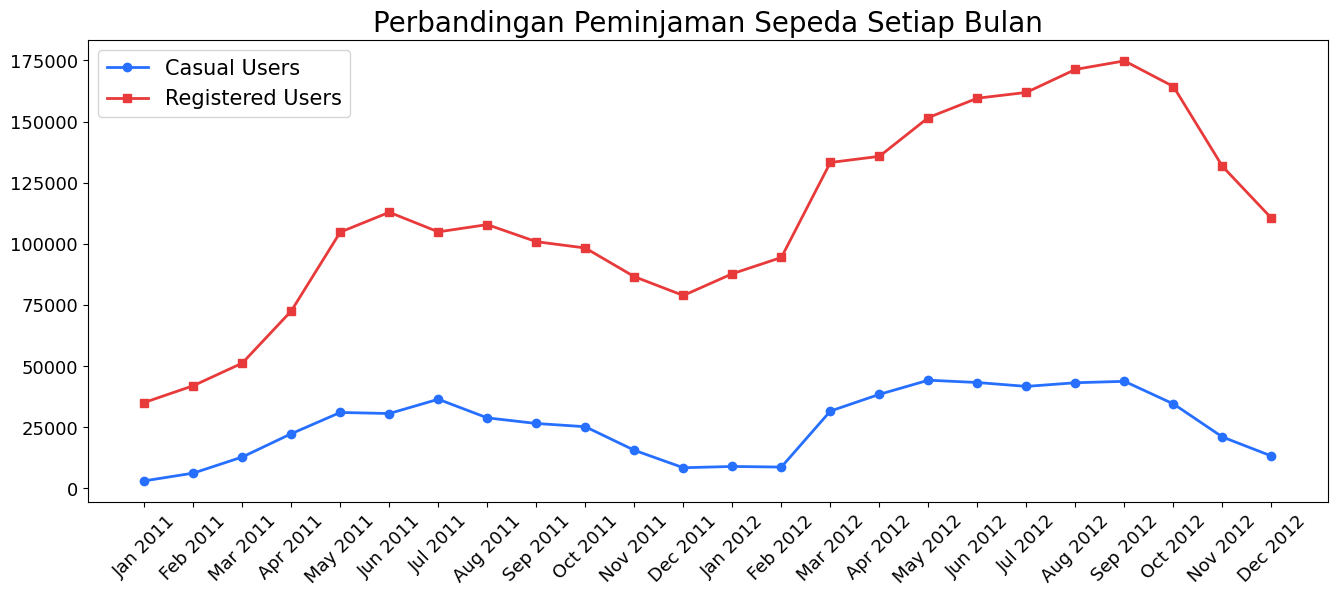

In [46]:
#menampilkan plot garis perbandingan antara casual dengan registered
plt.figure(figsize=(16, 6))
plt.plot(monthly_bike_dl['date'], monthly_bike_dl['casual'], marker='o', linewidth=2, color="#266fff", label='Casual Users')
plt.plot(monthly_bike_dl['date'], monthly_bike_dl['registered'], marker='s', linewidth=2, color="#e83a3a", label='Registered Users')
plt.title("Perbandingan Peminjaman Sepeda Setiap Bulan", loc="center", fontsize=20)
plt.xticks(fontsize=13)
plt.xticks(rotation=45)
plt.yticks(fontsize=13)
plt.legend(fontsize=15)
plt.show()

### Bagaimana tingkat frekuensi pengguna kasual atau terdaftar dalam peminjaman sepeda setiap jam nya?

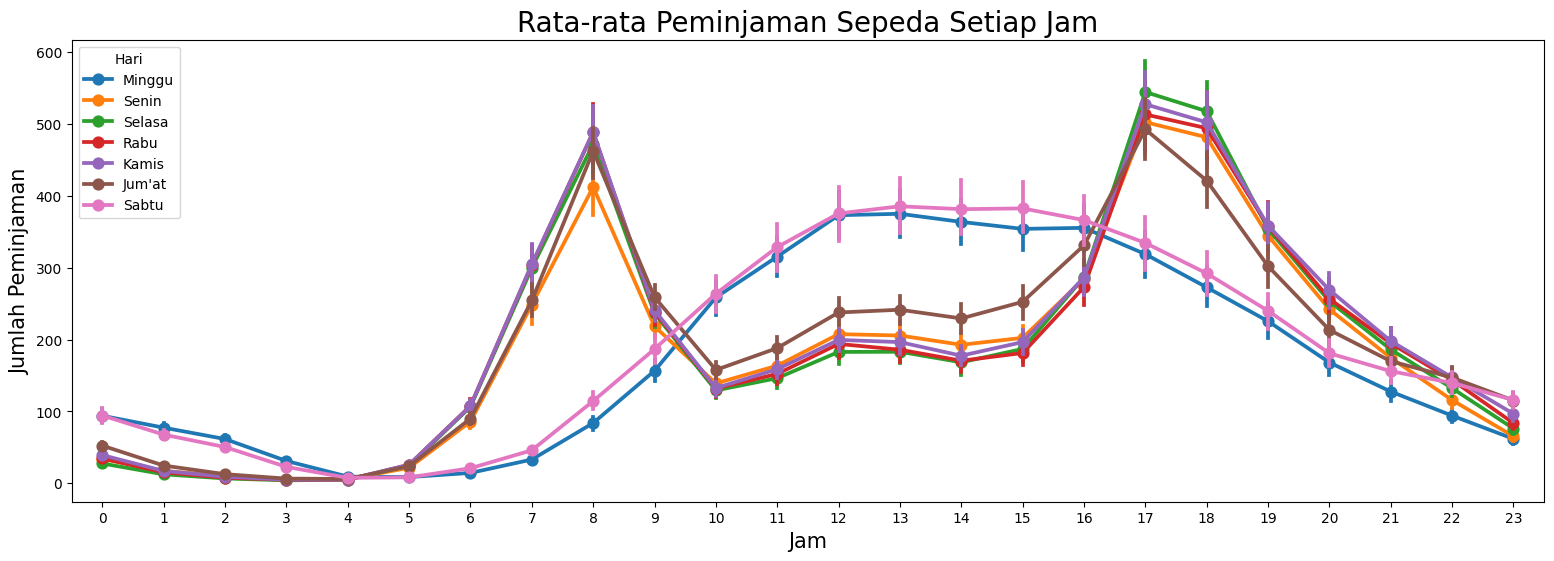

In [47]:
#Total peminjaman setiap jamnya
fig, ax = plt.subplots(figsize=(19,6))
sns.pointplot(data=hour_df, x='hour', y='total_users', hue='weekday', ax=ax)

ax.set_title('Rata-rata Peminjaman Sepeda Setiap Jam', size=20)
ax.set_xlabel('Jam', size = 15)
ax.set_ylabel('Jumlah Peminjaman', size = 15)
ax.legend(title='Hari', loc='upper left')

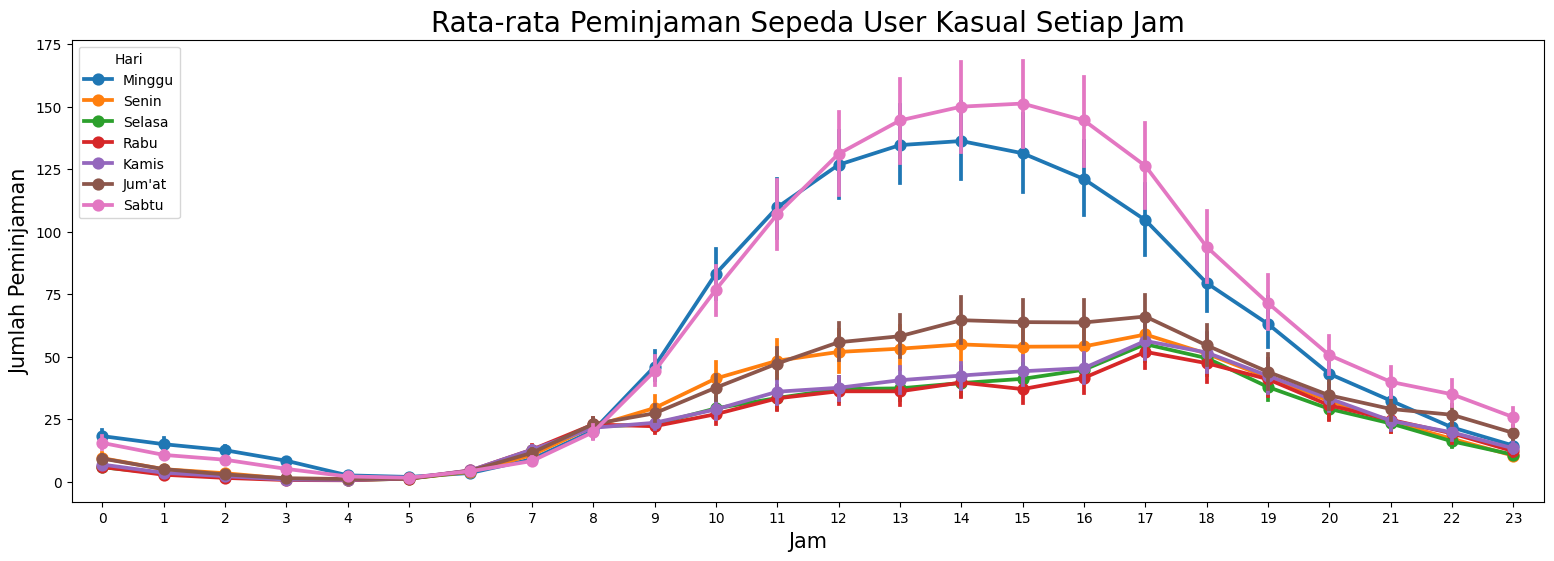

In [48]:
#Total peminjaman pengguna kasual setiap jamnya
fig, ax = plt.subplots(figsize=(19,6))
sns.pointplot(data=hour_df, x='hour', y='casual', hue='weekday', ax=ax)

ax.set_title('Rata-rata Peminjaman Sepeda User Kasual Setiap Jam', size=20)
ax.set_xlabel('Jam', size = 15)
ax.set_ylabel('Jumlah Peminjaman', size = 15)
ax.legend(title='Hari', loc='upper left')

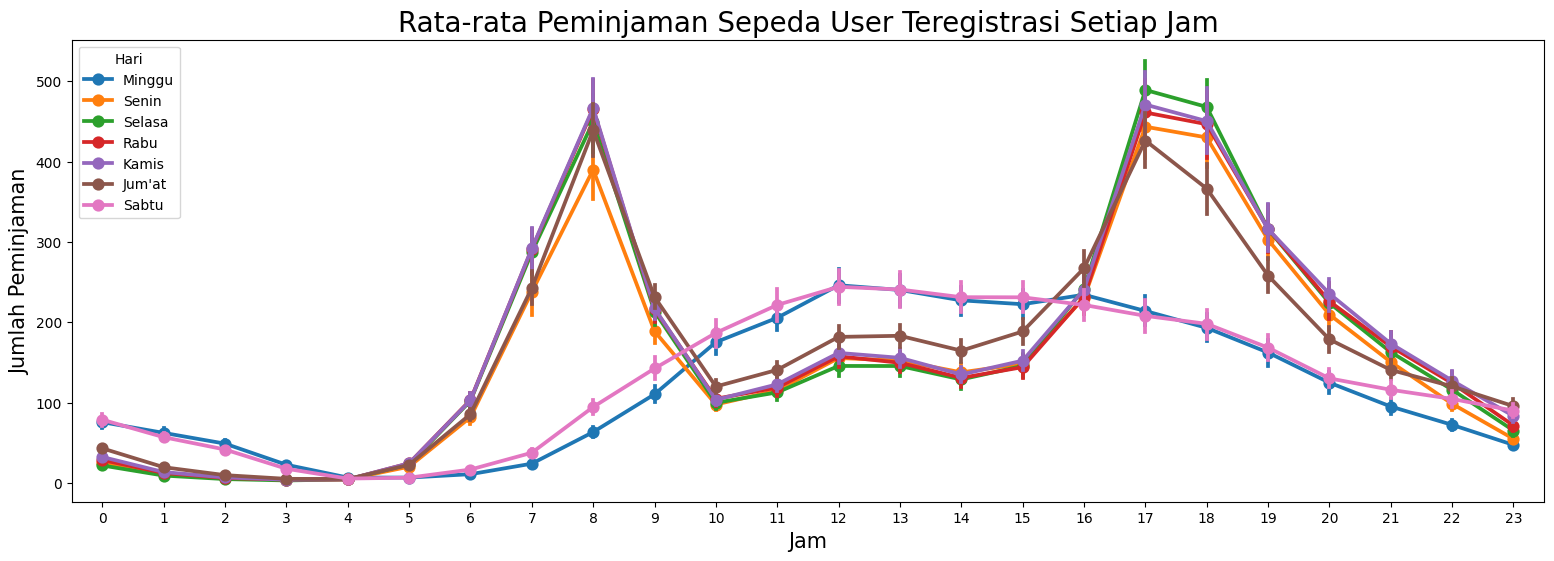

In [49]:
#Total peminjaman pengguna Teregistrasi setiap jamnya
fig, ax = plt.subplots(figsize=(19,6))
sns.pointplot(data=hour_df, x='hour', y='registered', hue='weekday', ax=ax)
#definisi nama
ax.set_title('Rata-rata Peminjaman Sepeda User Teregistrasi Setiap Jam', size=20)
ax.set_xlabel('Jam', size = 15)
ax.set_ylabel('Jumlah Peminjaman', size = 15)
ax.legend(title='Hari', loc='upper left')

###Bagaimana perbandingan peminjaman pengguna kasual dan terdaftar ketika waktu kerja atau libur?

Text(0.5, 0, '')

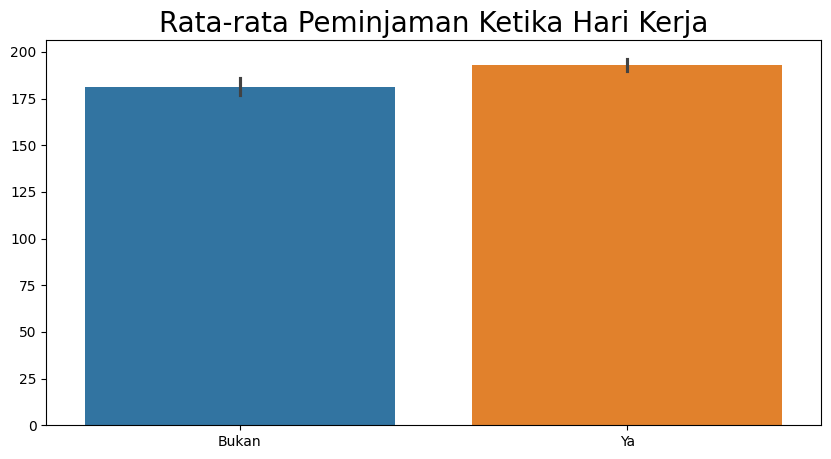

In [57]:
#Perbandingan barplot
fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(data=hour_df, x='is_workingday', y='total_users',hue='is_workingday', legend=False, ax=ax)
#definisi nama
ax.set_title('Rata-rata Peminjaman Ketika Hari Kerja', size=20)
ax.set_ylabel(None)
ax.set_xlabel(None)

Text(0.5, 0, '')

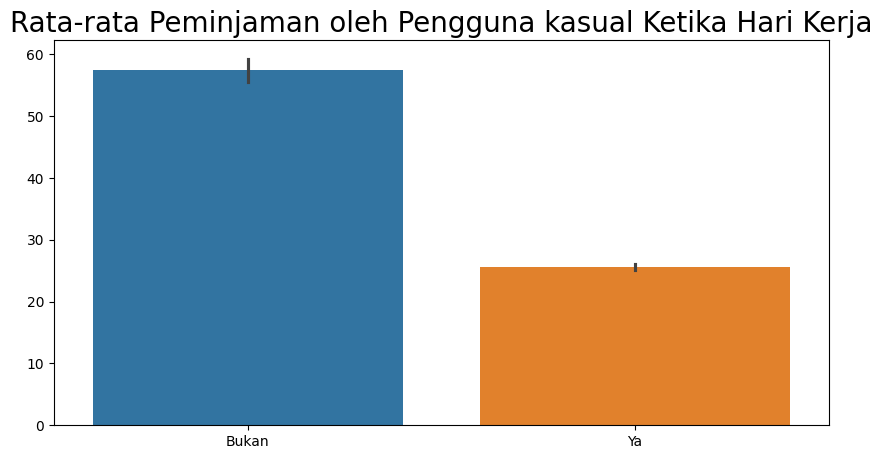

In [61]:
#Perbandingan barplot
fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(data=hour_df, x='is_workingday', y='casual', hue='is_workingday', legend=False, ax=ax)
#definisi nama
ax.set_title('Rata-rata Peminjaman oleh Pengguna kasual Ketika Hari Kerja', size=20)
ax.set_ylabel(None)
ax.set_xlabel(None)

Text(0.5, 0, '')

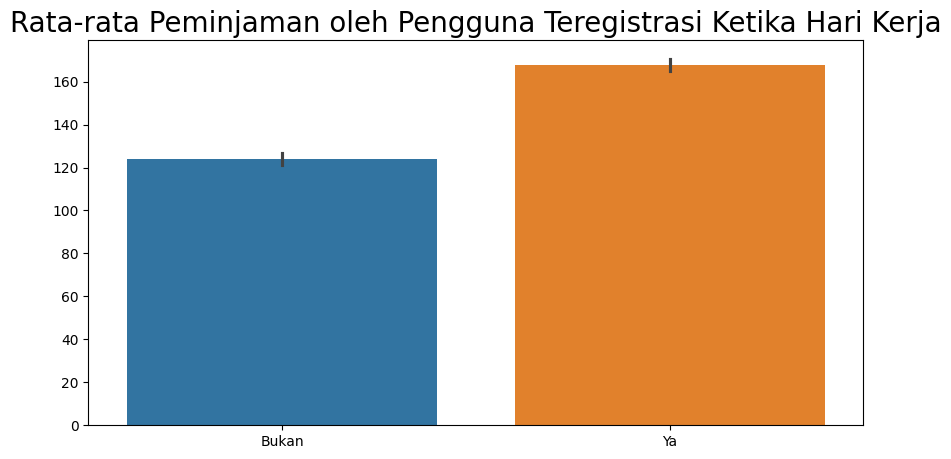

In [66]:
#Perbandingan barplot
fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(data=hour_df, x='is_workingday', y='registered', hue='is_workingday', legend=False, ax=ax)
#definisi nama
ax.set_title('Rata-rata Peminjaman oleh Pengguna Teregistrasi Ketika Hari Kerja', size=20)
ax.set_ylabel(None)
ax.set_xlabel(None)

Text(0.5, 0, '')

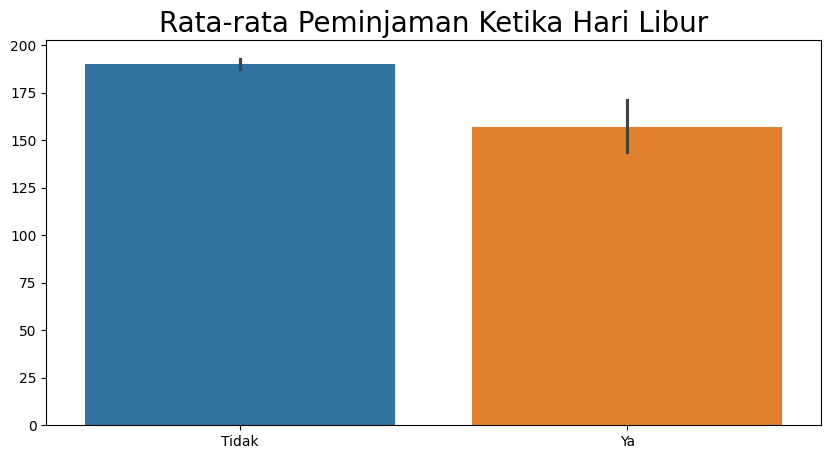

In [62]:
#Perbandingan barplot
fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(data=hour_df, x='is_holiday', y='total_users', hue= 'is_holiday', legend=False, ax=ax)
#definisi nama
ax.set_title('Rata-rata Peminjaman Ketika Hari Libur', size=20)
ax.set_ylabel(None)
ax.set_xlabel(None)

Text(0.5, 0, '')

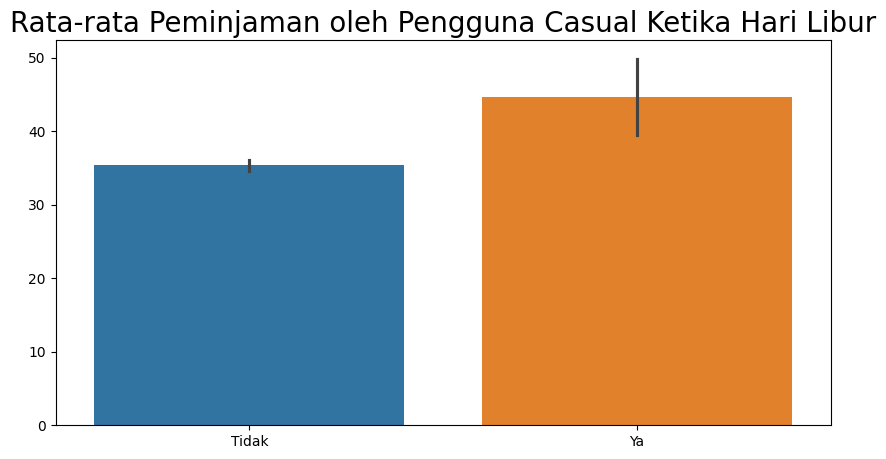

In [63]:
#Perbandingan barplot
fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(data=hour_df, x='is_holiday', y='casual', hue= 'is_holiday', legend=False, ax=ax)
#definisi nama
ax.set_title('Rata-rata Peminjaman oleh Pengguna Casual Ketika Hari Libur', size=20)
ax.set_ylabel(None)
ax.set_xlabel(None)

Text(0.5, 0, '')

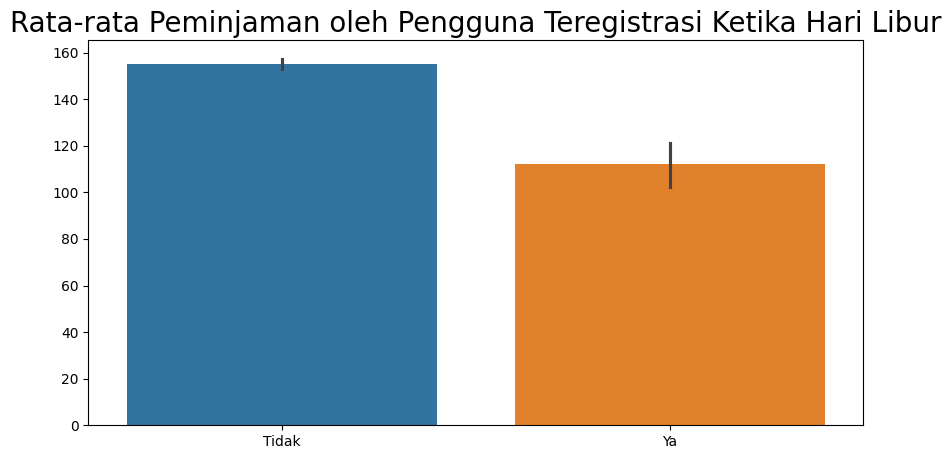

In [64]:
#Perbandingan barplot
fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(data=hour_df, x='is_holiday', y='registered', hue= 'is_holiday', legend=False, ax=ax)
#definisi nama
ax.set_title('Rata-rata Peminjaman oleh Pengguna Teregistrasi Ketika Hari Libur', size=20)
ax.set_ylabel(None)
ax.set_xlabel(None)

### Bagaimana tingkat peminjaman sepeda setiap musimnya selama dua tahun ini?

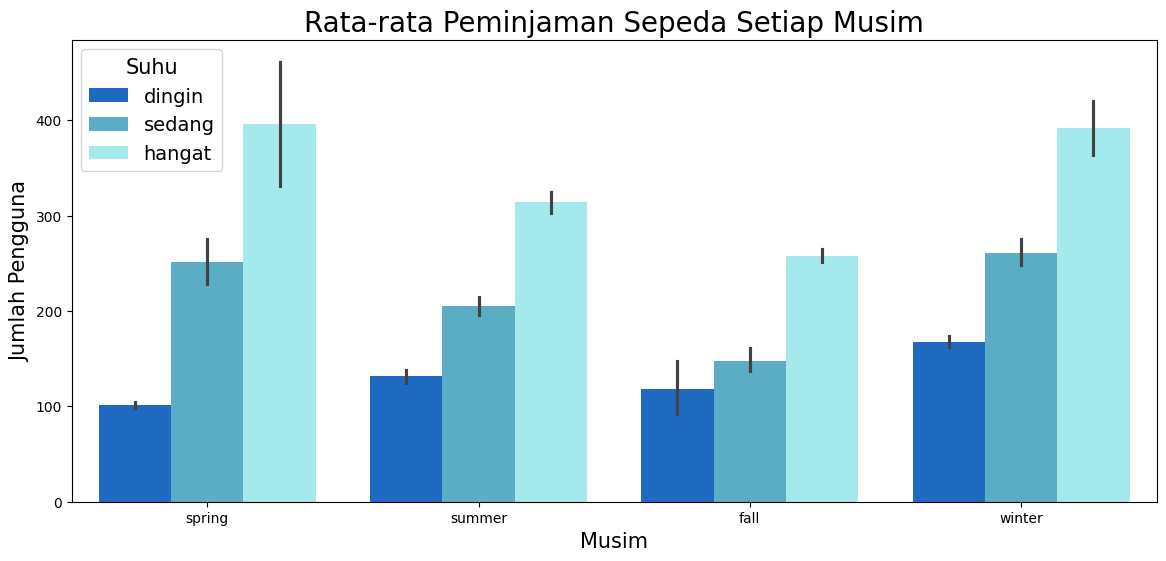

In [53]:
# perbandingan barplot total user berdasarkan musim, dimana setiap musim dibagi sesuai dengan kategori suhu
fig, ax = plt.subplots(figsize=(14,6))
sns.barplot(data=hour_df, x='season', y='total_users', hue= 'suhu',
            palette=["#0368DB", "#49B6D7", "#98F5F9"], ax=ax)
#definisi nama
ax.set_title('Rata-rata Peminjaman Sepeda Setiap Musim', size=20)
ax.set_ylabel("Jumlah Pengguna", size = 15)
ax.set_xlabel("Musim", size = 15)
ax.legend(title='Suhu', title_fontsize=15, loc='upper left', fontsize=14)

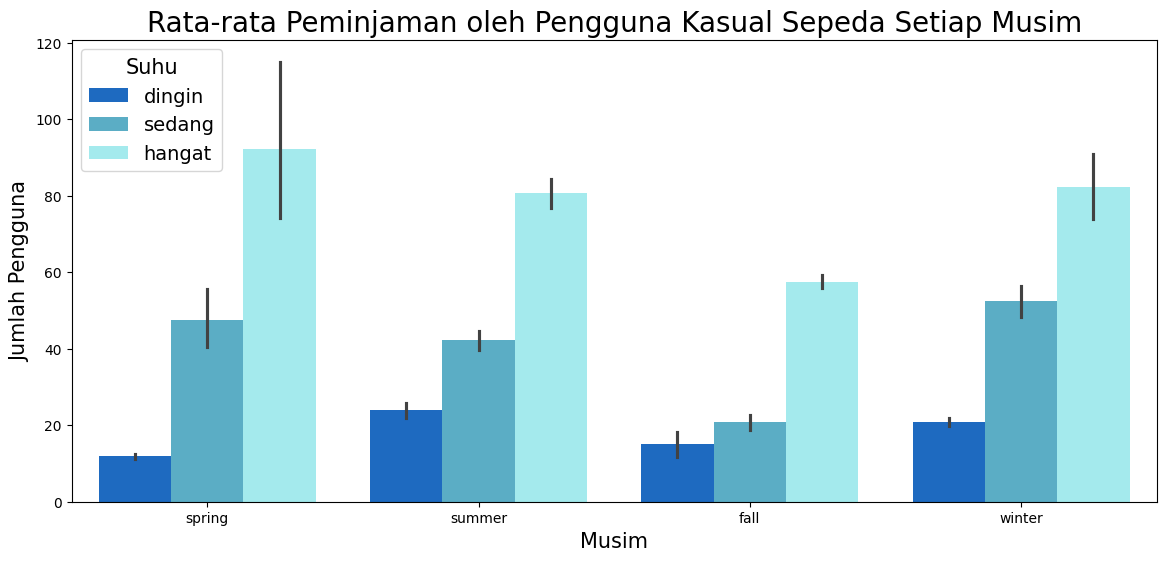

In [54]:
# perbandingan barplot total user berdasarkan musim, dimana setiap musim dibagi sesuai dengan kategori suhu
fig, ax = plt.subplots(figsize=(14,6))
sns.barplot(data=hour_df, x='season', y='casual', hue= 'suhu',
            palette=["#0368DB", "#49B6D7", "#98F5F9"], ax=ax)
#definisi nama
ax.set_title('Rata-rata Peminjaman oleh Pengguna Kasual Sepeda Setiap Musim', size=20)
ax.set_ylabel("Jumlah Pengguna", size = 15)
ax.set_xlabel("Musim", size = 15)
ax.legend(title='Suhu', title_fontsize=15, loc='upper left', fontsize=14)

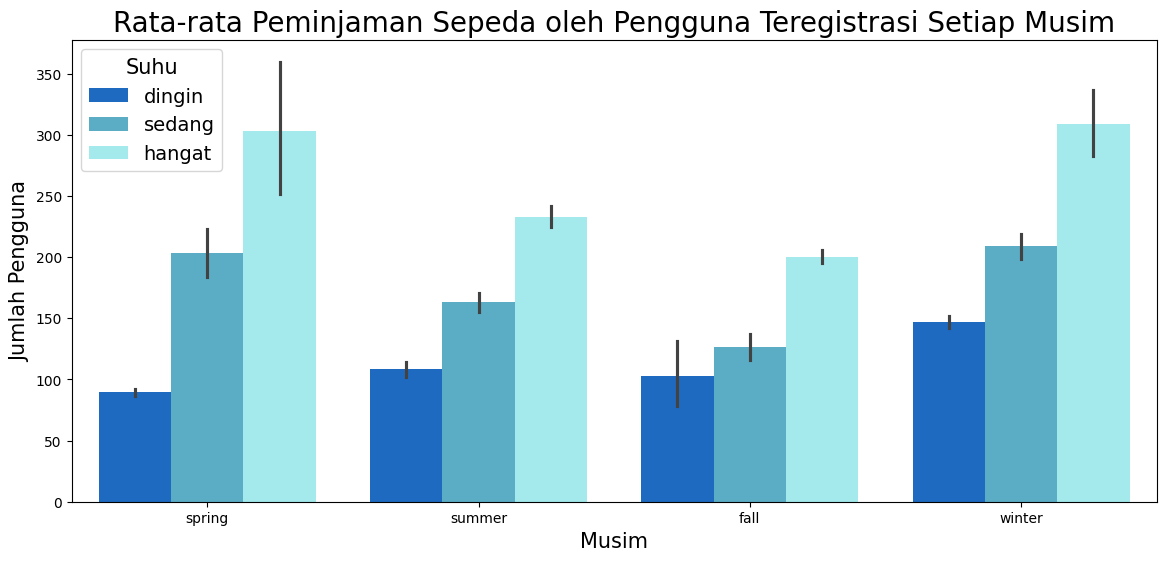

In [55]:
# perbandingan barplot total user berdasarkan musim, dimana setiap musim dibagi sesuai dengan kategori suhu
fig, ax = plt.subplots(figsize=(14,6))
sns.barplot(data=hour_df, x='season', y='registered', hue= 'suhu',
            palette=["#0368DB", "#49B6D7", "#98F5F9"], ax=ax)
#definisi nama
ax.set_title('Rata-rata Peminjaman Sepeda oleh Pengguna Teregistrasi Setiap Musim', size=20)
ax.set_ylabel("Jumlah Pengguna", size = 15)
ax.set_xlabel("Musim", size = 15)
ax.legend(title='Suhu', title_fontsize=15, loc='upper left', fontsize=14)

**Insight:**
- Peminjaman sepeda reltif banyak ketika memasuki pertengahan tahun, dan relatif kecil ketika akhir dan awal tahun, user kasual, maupun yang teregistrasi
- Peminjaman terihat menaik pesat pada hari senin - jumat pada waktu pagi dan sore dan menurun pada hari sabtu dan minggu
- Untuk Pengguna kasual relati lebih sering ketika memasuki hari sabtu dan minggu
- Untuk pengguna teregistrasi relatif lebis sering ketika memasuki hari senin - jumat
- Dominan pengguna lebih sering meminjam sepeda ketika suasana hangat (diatas 22°C) pada musim dingin dan semi

## Analisis Lanjutan (Opsional)

## Conclusion

- Conclution pertanyaan 1<br>
Peminjam sepeda pada awal tahun dan akhir tahun relatif lebih sedikit, terlihat penggunaan mulai menurun ketika memasuki bulan september yang merupakan masuknya musim gugur.<br><br>
Namun tingkat peminjaman mulai melonjak tinggi ketika melewati bulan maret, terutama mulai bulan maret pada tahun 2012.<br><br>
- Conclution pertanyaan 2 <br>
Peminjaman Relatif meningkat pesat ketika memasuki jam 6 dan jam 16 pada hari senin hingga jum'at, terutama pada pengguna teregistrasi yang dapat disimpulkan bahwa mereka menggunakan sepeda sebagai transportasi kerja.<br><br>
Peminjaman pada hari sabtu dan minggu mulai meningkat ketika memasuki jam 7 dan mulai menurun ketika memasuki waktu 17, terutama pada pengguna kasual yang dapat disimpulkan bahwa mereka menggunakaan pinjaman sepeda untuk olahraga/hiburan disaat weekend <br><br>
- Conclution pertanyaan 3<br>
Peminjaman oleh user kasual lebih sering disaat hari libur dan bukan bekerja, sebaliknya user teregistrasi relatif lebih sering meminjam ketika waktu kerja dan bukan libur <br><br>
- Conclution pertanyaan 4<br>
Peminjaman sepedah oleh user kasual dan teregistrasi relatif lebih sering ketika suhu mulai hangat.<br><br>
Ketika mulai memasuki musim gugur, tingkat peminjaman mulai menurun, terutama oleh pengguna kasual yang lebih kecil tingkat peminjamannya pada rentang suhu dingin dan sedang dibanding pengguna teregistrasi


In [68]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   borrow_id      17379 non-null  int64         
 1   date           17379 non-null  datetime64[ns]
 2   season         17379 non-null  category      
 3   year           17379 non-null  category      
 4   month          17379 non-null  category      
 5   hour           17379 non-null  category      
 6   is_holiday     17379 non-null  category      
 7   weekday        17379 non-null  category      
 8   is_workingday  17379 non-null  category      
 9   weathersit     17379 non-null  category      
 10  temp           17379 non-null  float64       
 11  atemp          17379 non-null  float64       
 12  hum            17379 non-null  float64       
 13  windspeed      17379 non-null  float64       
 14  casual         17379 non-null  int64         
 15  registered     1737

In [67]:
hour_df.to_csv("edited_hour.csv", index=False)